In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import datasets

In [3]:
class NaiveBayes:
    def __init__(self):
        self.classes = None
        self.mean = {}
        self.class_priors = {}
        self.variance = {}

    def fit(self, X, y):
        n_samples, n_features =  X.shape
        self.classes = np.unique(y)   # identify unique classes

        # calculate mean. variance and prior for each class
        for cls in self.classes:
            X_cls = X[y == cls]
            self.mean[cls] = np.mean(X_cls, axis=0)
            self.variance[cls] = np.var(X_cls, axis=0)
            self.class_priors[cls] = X_cls.shape[0] / n_samples

    def gaussian_density(self, x, mean, var):
        # calculate gaussian density function
        eps = 1e-6       # small constant to avoid division by 0
        coef = 1.0 / np.sqrt(2.0 * np.pi * var + eps)
        exponent = np.exp(-((x - mean)**2) / (2.0 * var + eps))
        return coef * exponent

    def class_likelihood(self, x, cls):
        # claculate the likelihood of a sample given a class
        mean = self.mean[cls]
        var = self.variance[cls]
        likelihoods = self.gaussian_density(x, mean, var)
        return np.prod(likelihoods)

    def predict(self, X):
        predictions = []
        for x in X:
            posteriors = {}
            for cls in self.classes:
                prior = np.log(self.class_priors[cls])
                likelihood = np.log(self.class_likelihood(x, cls))
                posteriors[cls] = prior + likelihood
            predictions.append(max(posteriors, key=posteriors.get))

        return np.array(predictions)


In [3]:
class Naive_Bayes:

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self._classes = np.unique(y)
        n_classes = len(self._classes)

        # calculate mean. variance and prior for each class
        self._mean = np.zeros((n_classes, n_features), dtype=np.float64)
        self._var = np.zeros((n_classes, n_features), dtype=np.float64)
        self._priors = np.zeros(n_classes, dtype=np.float64)

        for idx, c in enumerate(self._classes):
            X_c = X[y == c]
            self._mean[idx, :] = X_c.mean(axis = 0)
            self._var[idx, :] = X_c.var(axis = 0)
            self._priors[idx] = X_c.shape[0] / float(n_samples)

    def predict(self, X):
        y_pred = [self._predict(x) for x in X]
        return np.array(y_pred)

    def _predict(self, x):
        posteriors = []

        # claculate posterior probability for each class
        for idx, c in enumerate(self._classes):
            prior = np.log(self._priors[idx])
            posterior = np.sum(np.log(self._pdf(idx, x)))
            posterior = posterior + prior
            posteriors.append(posterior)

        # returning class with highest posterior
        return self._classes[np.argmax(posteriors)]

    # probability density function
    def _pdf(self, class_idx, x):
        mean = self._mean[class_idx]
        var = self._var[class_idx]
        numerator = np.exp(-((x - mean)**2) / (2.0 * var))
        denominator = np.sqrt(2 * np.pi * var)
        return numerator / denominator

In [4]:
def accuracy(y_true, y_pred):
    accuracy = np.sum(y_true == y_pred) / len(y_true)
    return accuracy

In [5]:
X, y = datasets.make_classification(
        n_samples=1000, n_features=10, n_classes=2, random_state=123
    )

X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=123
    )

In [6]:
nb = NaiveBayes()
nb.fit(X_train, y_train)
predictions = nb.predict(X_test)

In [7]:
print("Naive Bayes classification accuracy", accuracy(y_test, predictions))

Naive Bayes classification accuracy 0.965


### **1. Class Distribution**

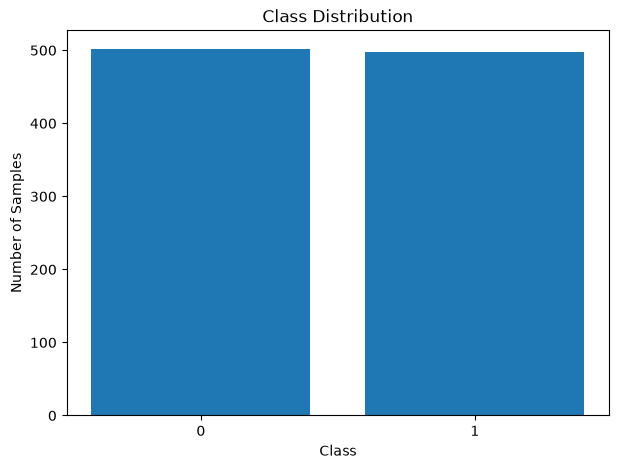

In [8]:
import matplotlib.pyplot as plt

classes, counts = np.unique(y, return_counts=True)

plt.figure(figsize=(7, 5))
plt.bar(classes.astype(str), counts)

plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")

plt.show()

### **2. Confusion Matrix**

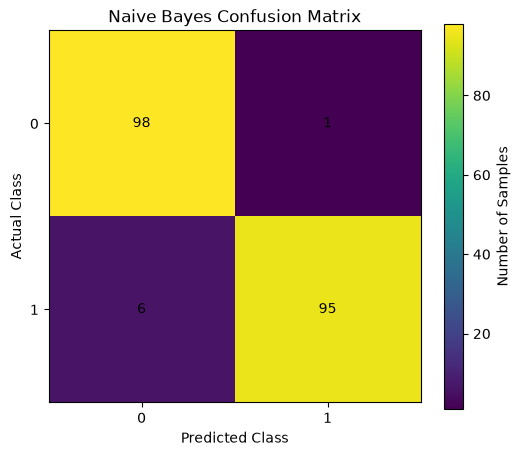

In [9]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(np.arange(len(nb.classes)), nb.classes)
plt.yticks(np.arange(len(nb.classes)), nb.classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.colorbar(label="Number of Samples")
plt.show()

### **3. Feature Distributions by Class**

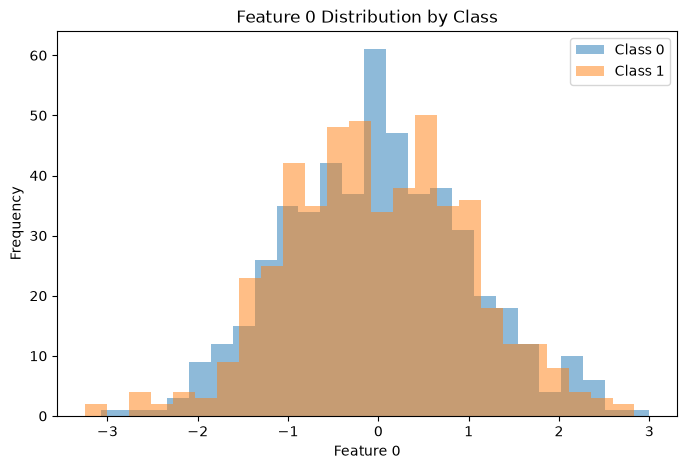

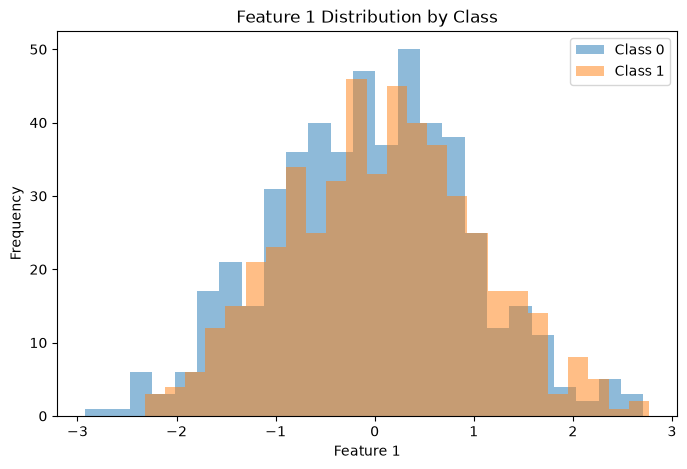

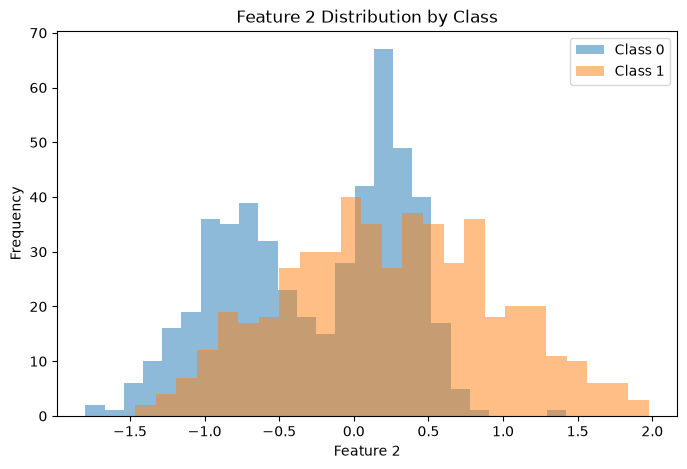

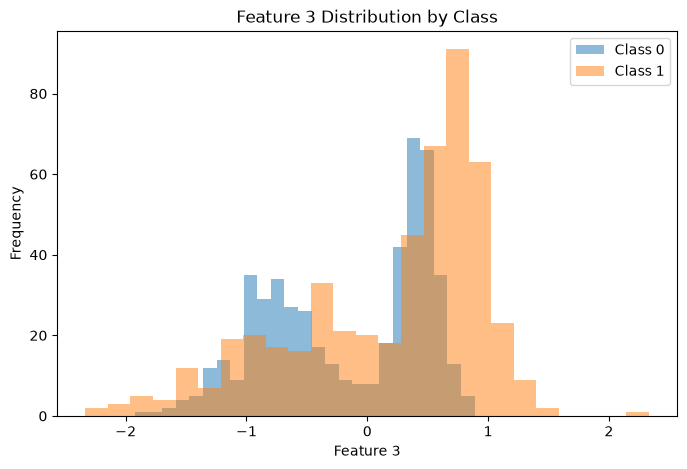

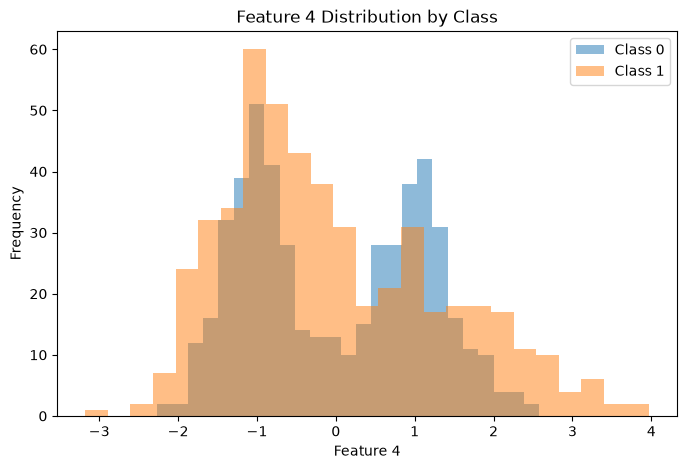

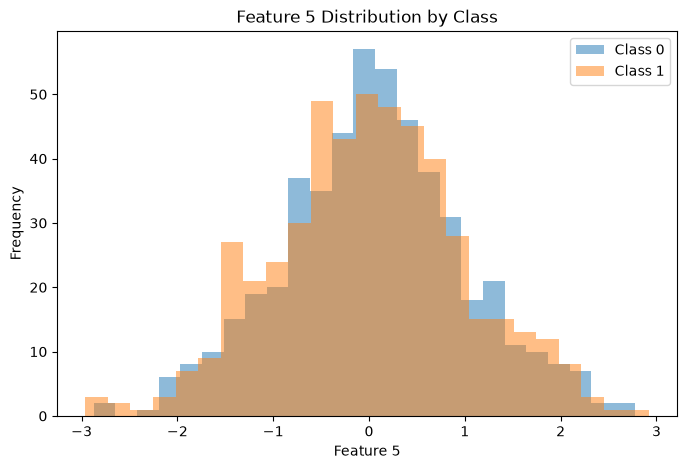

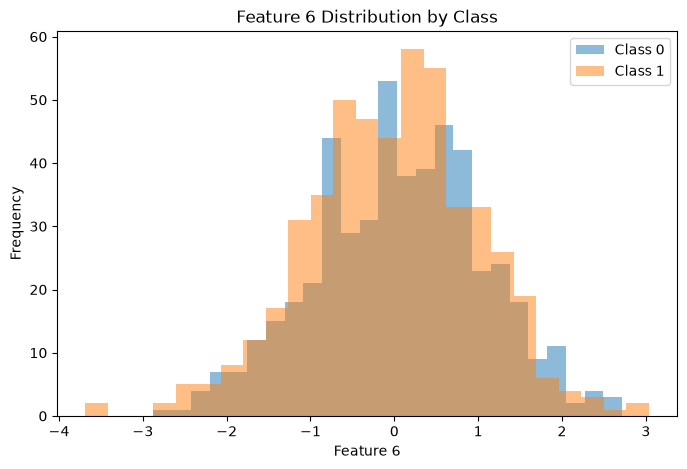

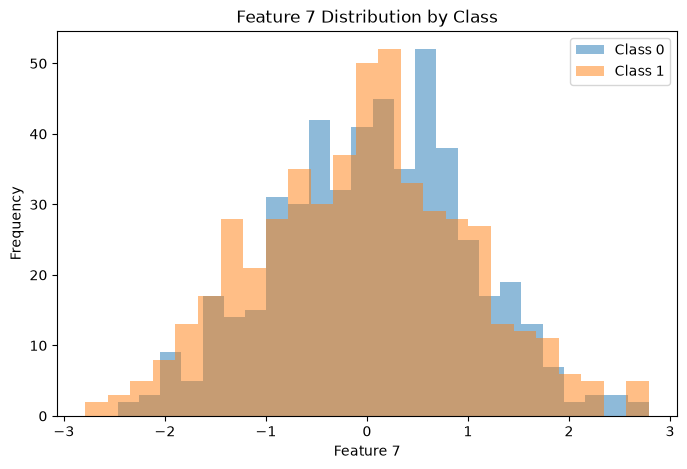

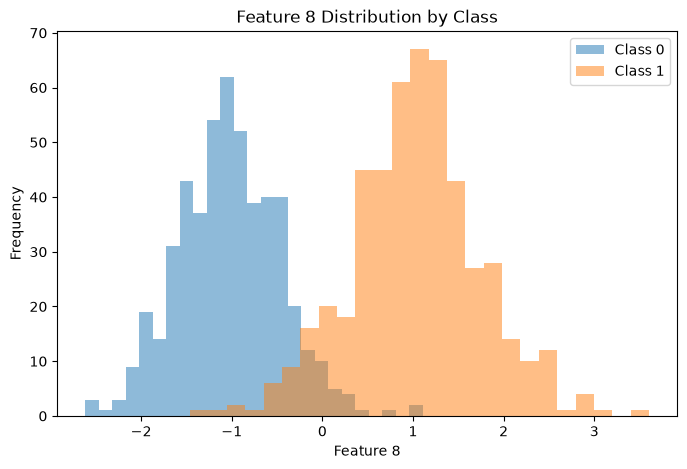

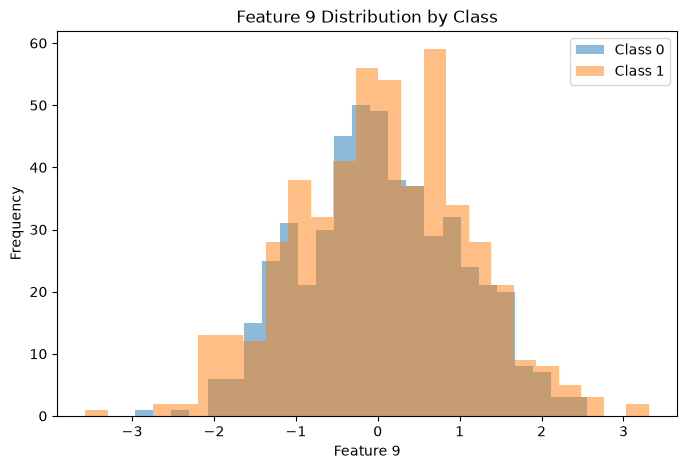

In [10]:
for feature_idx in range(X.shape[1]):

    plt.figure(figsize=(8, 5))

    for cls in nb.classes:
        feature_values = X[y == cls, feature_idx]

        plt.hist(
            feature_values,
            bins=25,
            alpha=0.5,
            label=f"Class {cls}"
        )

    plt.xlabel(f"Feature {feature_idx}")
    plt.ylabel("Frequency")
    plt.title(f"Feature {feature_idx} Distribution by Class")
    plt.legend()

    plt.show()

### **4. Learned Mean of Each Feature per Class**

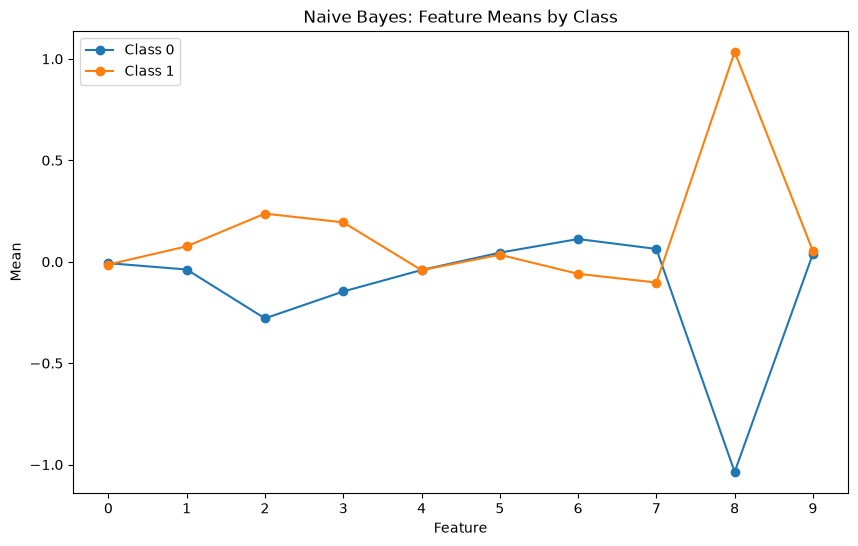

In [11]:
feature_indices = np.arange(X.shape[1])

plt.figure(figsize=(10, 6))

for cls in nb.classes:
    plt.plot(
        feature_indices,
        nb.mean[cls],
        marker="o",
        label=f"Class {cls}"
    )

plt.xlabel("Feature")
plt.ylabel("Mean")
plt.title("Naive Bayes: Feature Means by Class")
plt.xticks(feature_indices)
plt.legend()

plt.show()